#820 Project M2 Pet Cats in the UK Q3

---



**Section B Team 12**

**Kaixin Gao**

## Problem Statement and Analytic Focus


### Question 3 (M2)

This analysis focuses on whether gender is associated with different underlying spatial and living patterns among UK pet cats, or whether male and female cats share similar patterns with different distributions across them.

Since no finalized clustering structure has been established yet, this analysis constructs a preliminary representation of lifestyle and spatial patterns to support early-stage exploration.


### Q3 (M2): Does Gender Change Spatial–Lifestyle Patterns?

This section explores whether gender is associated with fundamentally different spatial and living patterns among UK pet cats, or whether male and female cats share similar patterns but differ mainly in how they are distributed across them.

The analysis is exploratory and aims to identify early structural signals rather than final segmentation.


## Project Motivation & Problem Statement: What Changed and Why

During the M2 phase, we observed substantial scale heterogeneity between the raw spatial variables and lifestyle-related features, along with the presence of missing values and outliers. This creates a risk that hierarchical clustering may be dominated by a small subset of high-variance features, rather than capturing meaningful behavioral structure.

To address this issue, we refined our workflow by:

(1) aggregating GPS records into a tag-level feature table;

(2) applying median imputation and standardized scaling prior to clustering; and

(3) conducting a parameter sweep over multiple values of k to assess the stability of the discovered structure.

Conceptually, the focus of Q3 was reframed from “re-clustering by gender” to “identifying shared latent spatial–lifestyle structures and then overlaying gender information to test whether observed differences are structural or distributional in nature.”

Finally, we introduced KMeans as a complementary unsupervised method and quantified cross-method consistency using the Adjusted Rand Index (ARI) to strengthen the robustness of our conclusions.

## Data Overview

###Data Import and Preparation

In [1]:
import pandas as pd
import numpy as np

cats_gps_url = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2023/2023-01-31/cats_uk.csv"
cats_meta_url = "https://raw.githubusercontent.com/rfordatascience/tidytuesday/main/data/2023/2023-01-31/cats_uk_reference.csv"
cats_gps = pd.read_csv(cats_gps_url)
cats_meta = pd.read_csv(cats_meta_url)
print("GPS dataset shape:", cats_gps.shape)
print("Metadata dataset shape:", cats_meta.shape)

GPS dataset shape: (18215, 11)
Metadata dataset shape: (101, 16)


In [2]:
cats_gps.head()

,tag_id,event_id,visible,timestamp,location_long,location_lat,ground_speed,height_above_ellipsoid,algorithm_marked_outlier,manually_marked_outlier,study_name
0,Ares,3395610551,True,2017-06-24T01:03:57Z,-5.113851,50.170315,684,154.67,False,False,Pet Cats United Kingdom
1,Ares,3395610552,True,2017-06-24T01:11:20Z,-5.113851,50.170315,936,154.67,False,False,Pet Cats United Kingdom
2,Ares,3395610553,True,2017-06-24T02:58:16Z,-5.113730,50.169876,2340,81.35,False,False,Pet Cats United Kingdom
3,Ares,3395610554,True,2017-06-24T03:01:26Z,-5.113774,50.169827,0,67.82,False,False,Pet Cats United Kingdom
4,Ares,3395610555,True,2017-06-24T03:51:58Z,-5.114247,50.170139,4896,118.03,False,False,Pet Cats United Kingdom


In [3]:
cats_meta.head()

,tag_id,animal_id,animal_taxon,deploy_on_date,deploy_off_date,hunt,prey_p_month,animal_reproductive_condition,animal_sex,hrs_indoors,n_cats,food_dry,food_wet,food_other,study_site,age_years
0,Tommy-Tag,Tommy,Felis catus,2017-06-03T01:02:09Z,2017-06-10T02:10:52Z,True,12.5,Neutered,m,12.5,2,True,True,False,UK,11.0
1,Athena,Athena,Felis catus,2017-06-24T01:02:13Z,2017-06-30T23:59:32Z,True,3.0,Spayed,f,7.5,2,True,True,False,UK,3.0
2,Ares,Ares,Felis catus,2017-06-24T01:03:57Z,2017-06-30T23:58:01Z,NaN,0.0,Neutered,m,7.5,2,True,True,False,UK,3.0
3,Lola,Lola,Felis catus,2017-06-24T01:18:49Z,2017-06-30T09:04:40Z,True,3.0,Spayed,f,17.5,1,True,True,False,UK,10.0
4,Maverick,Maverick,Felis catus,2017-06-25T01:04:35Z,2017-07-03T09:10:07Z,True,3.0,Neutered,m,12.5,1,True,True,True,UK,7.0


In [4]:
cats_gps.describe()

,event_id,location_long,location_lat,ground_speed,height_above_ellipsoid
count,1.821500e+04,18215.000000,18215.000000,18215.000000,18215.000000
mean,3.618912e+09,-4.988242,50.296238,1911.484381,103.648265
std,1.934048e+08,0.301499,0.158353,4592.574178,245.705665
min,3.395611e+09,-5.758854,50.103519,0.000000,-550.070000
25%,3.459216e+09,-5.157051,50.153644,396.000000,48.870000
50%,3.544858e+09,-5.073365,50.236397,1080.000000,80.920000
75%,3.716220e+09,-4.795648,50.428098,2232.000000,119.430000
max,4.149498e+09,-4.208614,50.882217,277092.000000,8388.260000


In [5]:
cats_meta.describe()

,prey_p_month,hrs_indoors,n_cats,age_years
count,101.000000,101.000000,101.000000,100.000000
mean,3.742574,11.856436,2.079208,5.420000
std,4.831467,5.227971,0.996827,3.384994
min,0.000000,2.500000,1.000000,0.000000
25%,0.500000,7.500000,1.000000,3.000000
50%,3.000000,12.500000,2.000000,5.000000
75%,3.000000,17.500000,3.000000,8.000000
max,17.500000,22.500000,4.000000,16.000000


In [6]:
full_cats_data = cats_gps.merge(
    cats_meta,
    on='tag_id',
    how='left'
)


In [7]:
cleaned_cats_data = full_cats_data[~full_cats_data['tag_id'].isin(['Ares', 'Wilfred-Tag', 'Lightening Bugg-Tag', 'Jezebel-Tag','Tipsy-Tag','Maggie-Tag','Lily-Tag','Pants-Tag','Neil-Tag','Johnny-Tag','Meg-Tag','Amber-Tag','Charlie3-Tag'])]
cleaned_cats_data = cleaned_cats_data.drop('food_other', axis=1)
cleaned_cats_data

,tag_id,event_id,visible,timestamp,location_long,location_lat,ground_speed,height_above_ellipsoid,algorithm_marked_outlier,manually_marked_outlier,...,hunt,prey_p_month,animal_reproductive_condition,animal_sex,hrs_indoors,n_cats,food_dry,food_wet,study_site,age_years
103,Athena,3395610893,True,2017-06-24T01:02:13Z,-5.114018,50.170296,360,78.04,False,False,...,True,3.0,Spayed,f,7.5,2,True,True,UK,3.0
104,Athena,3395610894,True,2017-06-24T01:05:33Z,-5.113985,50.170277,828,70.43,False,False,...,True,3.0,Spayed,f,7.5,2,True,True,UK,3.0
105,Athena,3395610895,True,2017-06-24T02:12:30Z,-5.114270,50.170177,288,65.66,False,False,...,True,3.0,Spayed,f,7.5,2,True,True,UK,3.0
106,Athena,3395610896,True,2017-06-24T02:15:29Z,-5.114331,50.170170,0,75.44,False,False,...,True,3.0,Spayed,f,7.5,2,True,True,UK,3.0
107,Athena,3395610897,True,2017-06-24T05:30:58Z,-5.114207,50.170303,792,68.41,False,False,...,True,3.0,Spayed,f,7.5,2,True,True,UK,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18210,Millie-Tag,4149497976,True,2017-11-26T15:37:52Z,-4.521489,50.869320,1260,144.66,False,False,...,True,7.5,Spayed,f,12.5,2,False,True,UK,3.0
18211,Millie-Tag,4149497977,True,2017-11-26T15:40:59Z,-4.521498,50.869289,16380,136.60,False,False,...,True,7.5,Spayed,f,12.5,2,False,True,UK,3.0
18212,Millie-Tag,4149497978,True,2017-11-26T16:27:31Z,-4.521803,50.869438,4500,160.97,False,False,...,True,7.5,Spayed,f,12.5,2,False,True,UK,3.0
18213,Millie-Tag,4149497979,True,2017-11-26T16:34:26Z,-4.521946,50.869392,1044,179.81,False,False,...,True,7.5,Spayed,f,12.5,2,False,True,UK,3.0


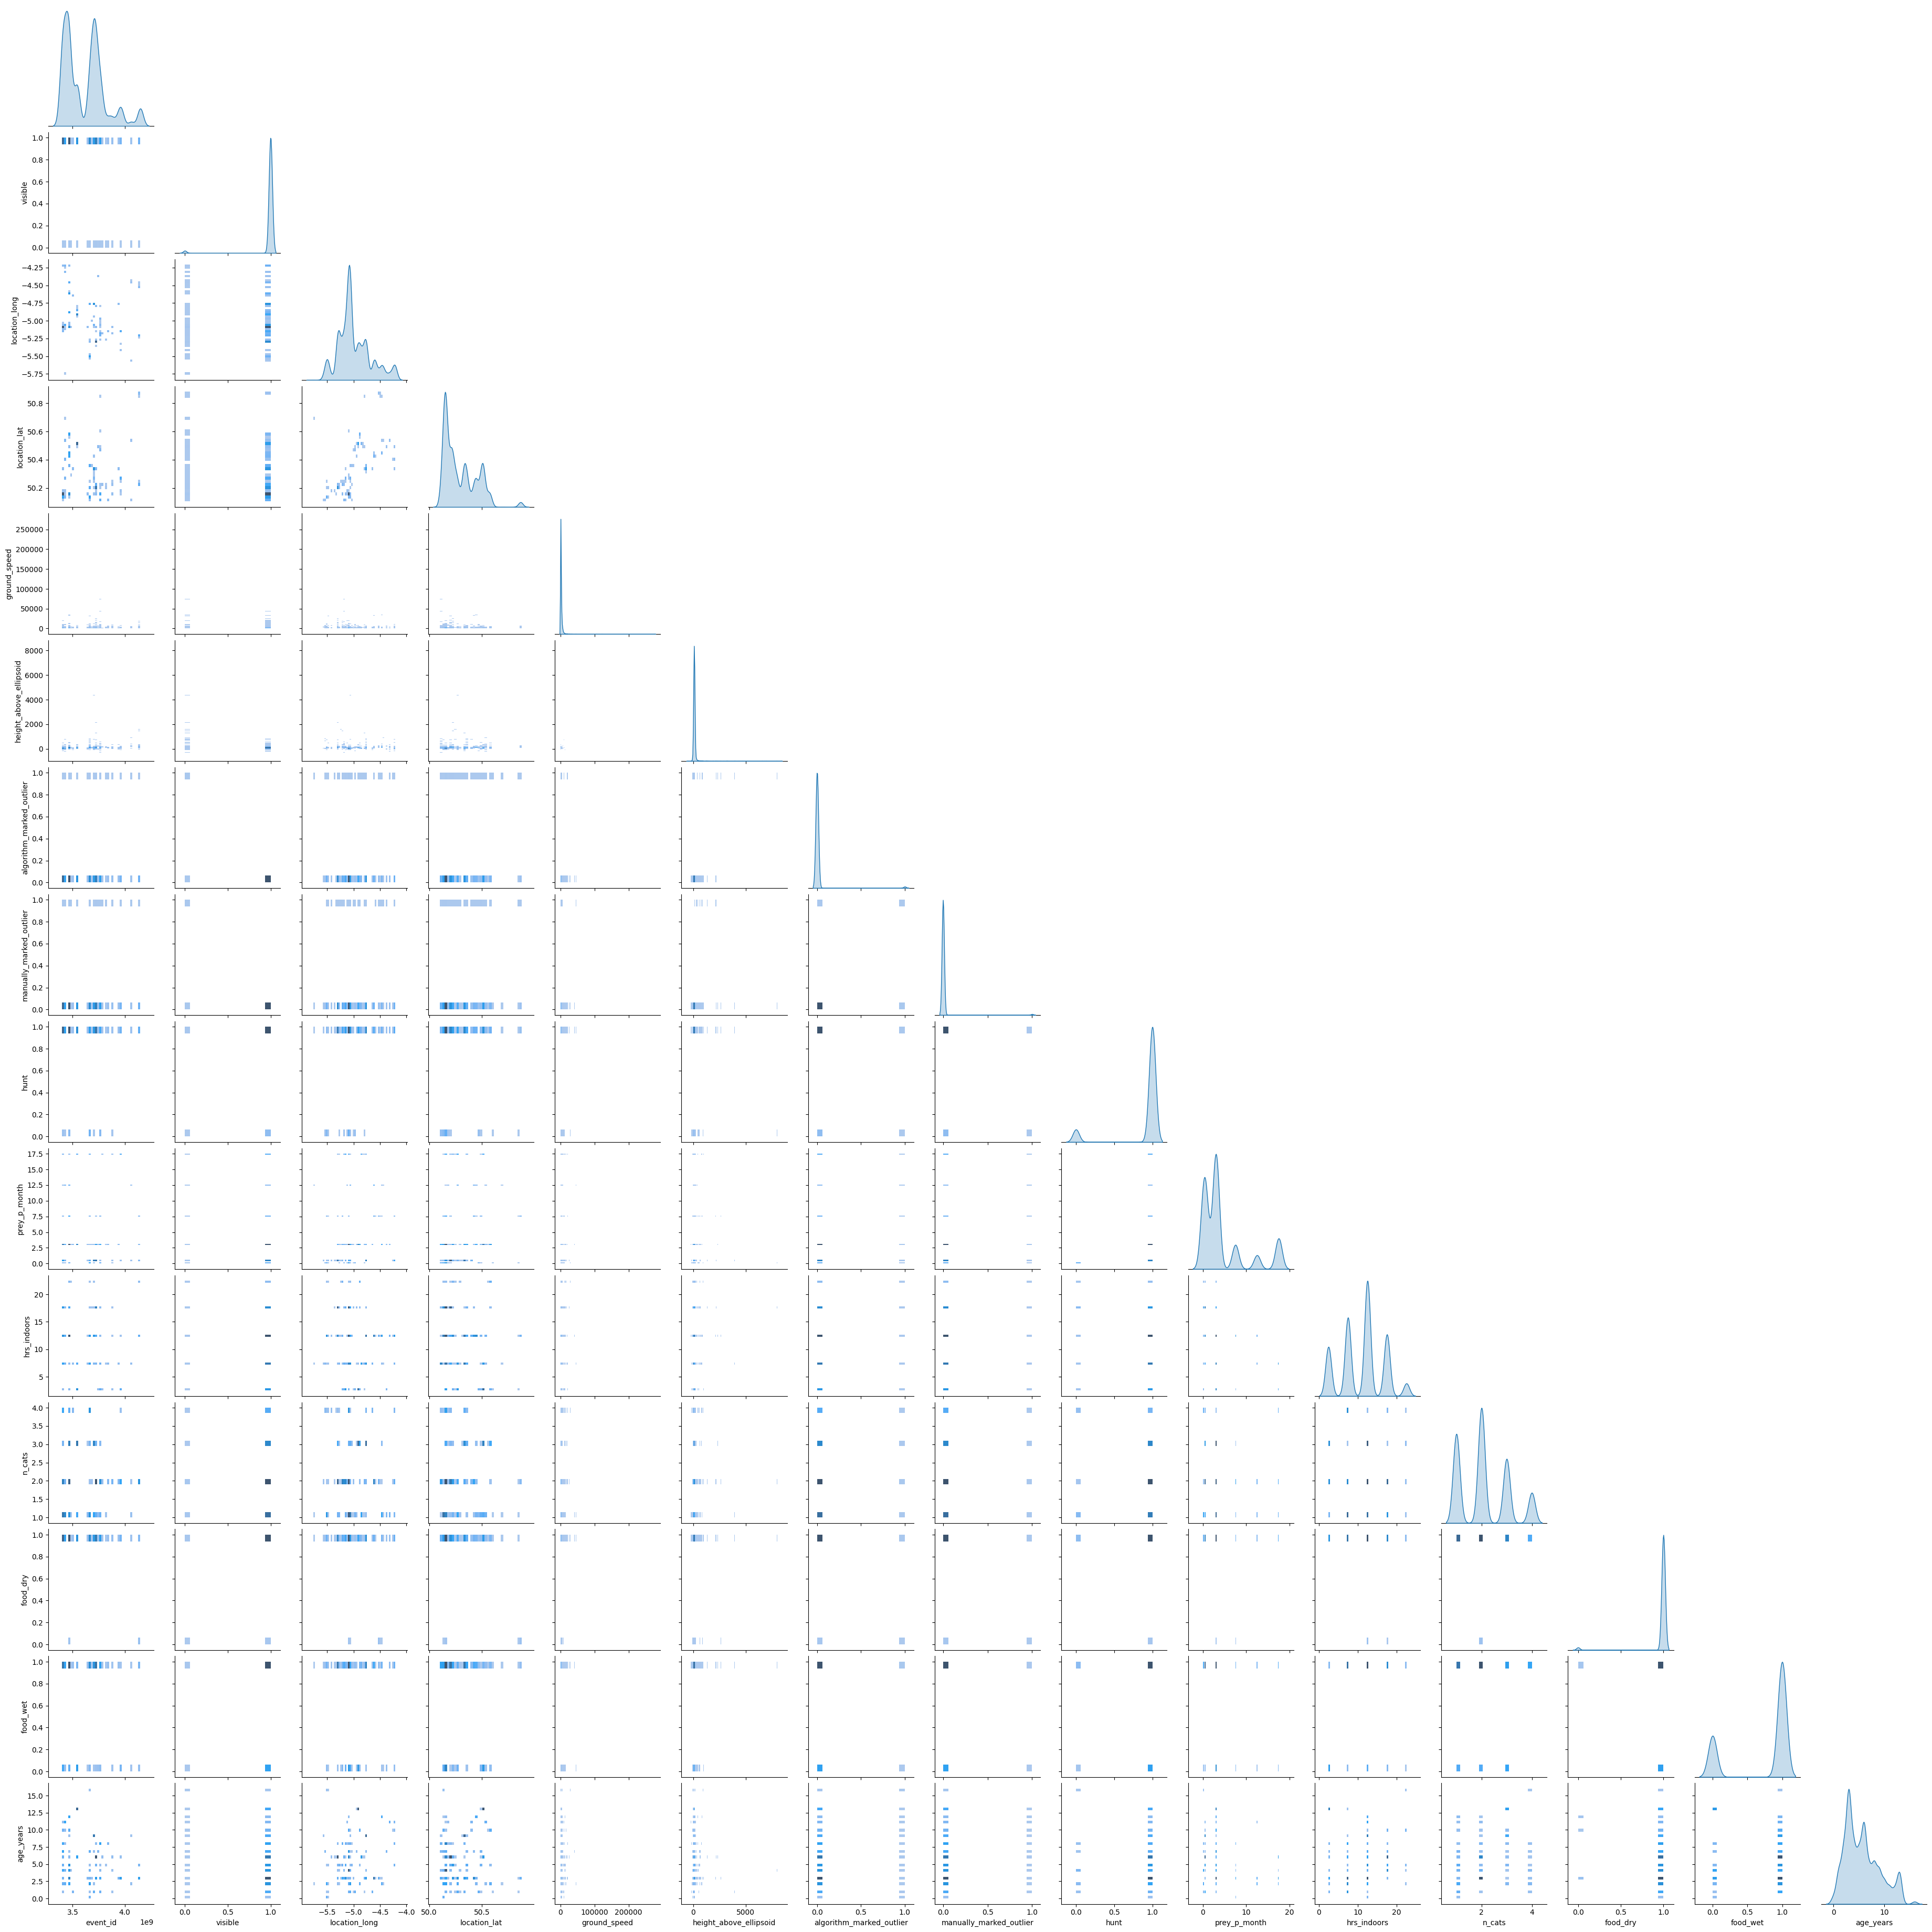

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.pairplot(cleaned_cats_data, kind="hist", diag_kind="kde", corner=True)

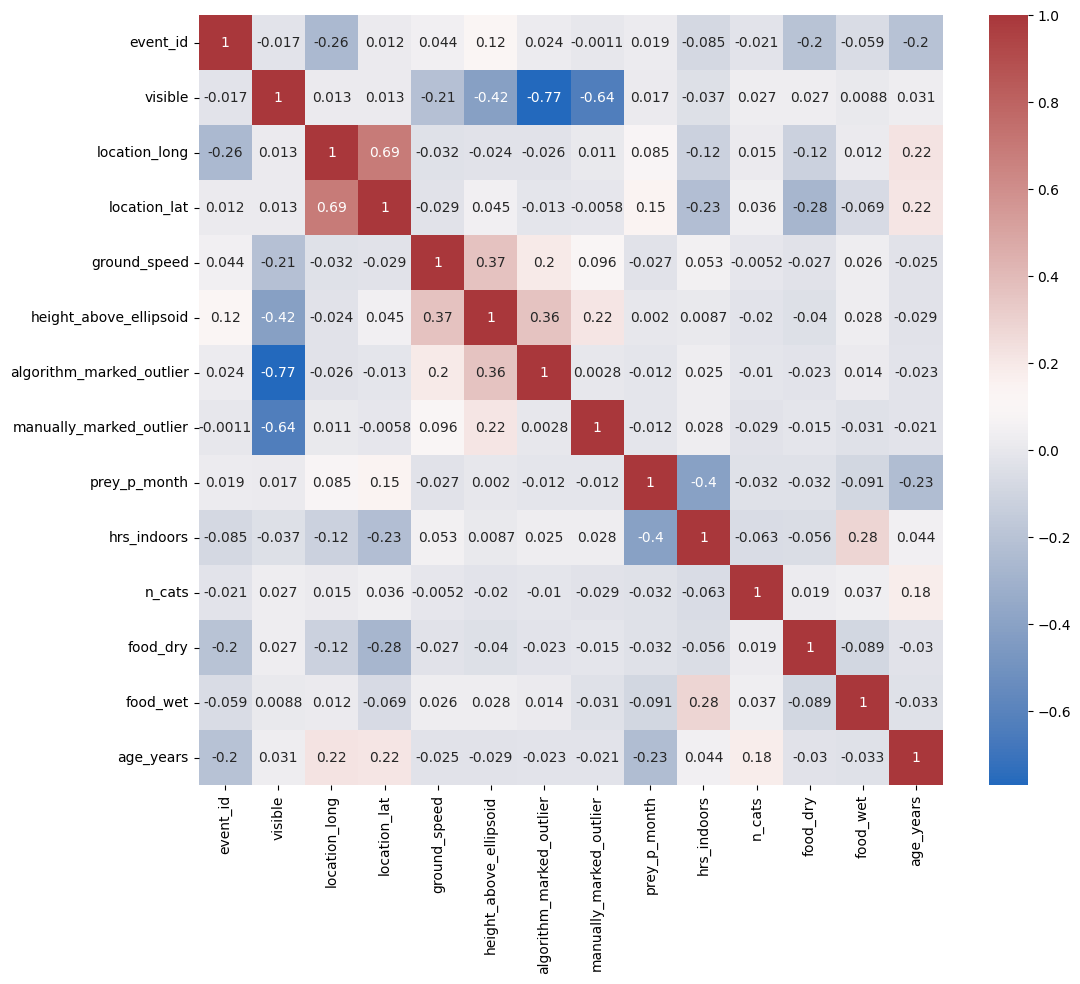

In [9]:
corr = cleaned_cats_data.corr(numeric_only=True)
plt.figure(figsize=(12, 10))
corr = cleaned_cats_data.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="vlag")
plt.show()

In [10]:
numeric_cols = [
    'location_long', 'location_lat',
    'ground_speed', 'height_above_ellipsoid',
    'algorithm_marked_outlier', 'manually_marked_outlier',
]

meta_numeric_cols = [
    'hunt', 'prey_p_month',
    'hrs_indoors', 'n_cats',
    'food_dry', 'food_wet',
    'age_years'
]



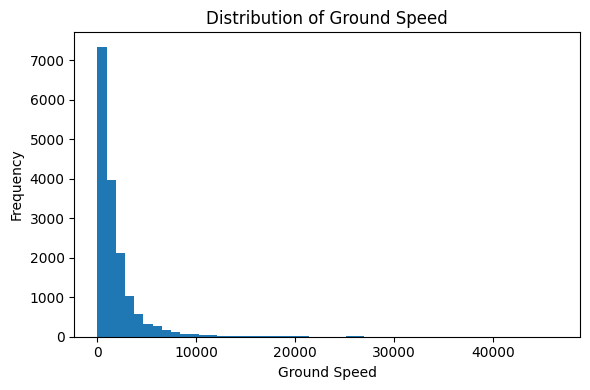

In [11]:
cleaned_cats_data = cleaned_cats_data[cleaned_cats_data['ground_speed'] < 50000]
plt.figure(figsize=(6,4))
plt.hist(cleaned_cats_data['ground_speed'].dropna(), bins=50)
plt.title('Distribution of Ground Speed')
plt.xlabel('Ground Speed')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

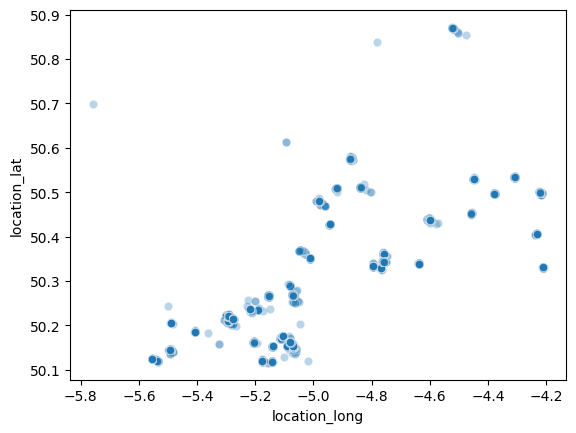

In [12]:
sns.scatterplot(data = cleaned_cats_data[numeric_cols], x = 'location_long', y = 'location_lat', alpha=0.3)
plt.show()

## EDA Updates
**Key Finding:** Cats exhibit substantial heterogeneity in their activity ranges. The distribution of spatial variability indicates that movement patterns do not form a smooth continuum from short-range to long-range roaming. Instead, cats separate into several clearly distinct groups with markedly different latitude and longitude fluctuations, suggesting fundamentally different roaming behaviors.


**Methodological Challenge:** It remains unclear whether observations associated with extremely high speeds or unusually long distances reflect genuine animal behavior or are artifacts of GPS signal noise. As a result, data filtering and standardization are necessary prior to analysis to prevent such outliers from disproportionately influencing the clustering results.


**Interpretive Insight:** Lifestyle-related behaviors—such as time spent indoors and frequency of hunting activity—co-vary with spatial range. This implies that the clusters identified represent not merely geographic groupings, but broader lifestyle archetypes, such as long-range, hunting-oriented roamers versus predominantly indoor, low-mobility cats.

## Preprocessing Updates

We aggregate GPS-level records to tag-level features (mean/std/max) to align the unit of analysis with Q3 (cat-level structure).

We remove algorithm/manually marked outliers when available to avoid clusters driven by noise.

We apply median imputation for missing values and standard scaling to ensure Ward linkage is not dominated by high-variance variables.

### Build cat-level feature table

In [13]:
df = cleaned_cats_data.copy()

if 'algorithm_marked_outlier' in df.columns:
    df = df[df['algorithm_marked_outlier'] != 1]
if 'manually_marked_outlier' in df.columns:
    df = df[df['manually_marked_outlier'] != 1]

agg_dict = {
    'location_lat': ['mean', 'std'],
    'location_long': ['mean', 'std'],
    'ground_speed': ['mean', 'std', 'max'],
    'height_above_ellipsoid': ['mean', 'std']
}

cat_level = df.groupby('tag_id').agg(agg_dict)
cat_level.columns = ['_'.join(col).strip() for col in cat_level.columns]
cat_level = cat_level.reset_index()

meta_cols = ['tag_id', 'animal_sex', 'hrs_indoors', 'hunt', 'prey_p_month', 'n_cats']
meta_keep = cats_meta[meta_cols].drop_duplicates('tag_id')

cat_level = cat_level.merge(meta_keep, on='tag_id', how='left')

cat_level.head()


,tag_id,location_lat_mean,location_lat_std,location_long_mean,location_long_std,ground_speed_mean,ground_speed_std,ground_speed_max,height_above_ellipsoid_mean,height_above_ellipsoid_std,animal_sex,hrs_indoors,hunt,prey_p_month,n_cats
0,Abba-Tag,50.163348,0.000226,-5.204581,0.000412,1453.170732,1663.014248,7308,157.563659,61.086201,f,7.5,True,3.0,2
1,Alfie-Tag,50.344323,0.000870,-4.759988,0.001753,1931.679144,2413.262206,14652,82.725668,102.561322,m,7.5,True,3.0,2
2,Athena,50.170166,0.000247,-5.114081,0.000416,2134.188679,2685.603928,19728,87.520283,44.317564,f,7.5,True,3.0,2
3,Balu-Tag,50.496859,0.000356,-4.377611,0.000645,1825.111111,2237.968300,14220,161.653704,45.015252,f,2.5,True,3.0,1
4,Barney-Tag,50.406121,0.000408,-4.232356,0.000461,1646.709677,1775.056549,10548,42.765806,31.022332,m,12.5,True,0.5,2


In [37]:
print(cat_level.isnull().sum())


tag_id                         0
location_lat_mean              0
location_lat_std               0
location_long_mean             0
location_long_std              0
ground_speed_mean              0
ground_speed_std               0
ground_speed_max               0
height_above_ellipsoid_mean    0
height_above_ellipsoid_std     0
animal_sex                     0
hrs_indoors                    0
hunt                           0
prey_p_month                   0
n_cats                         0
cluster_labels                 0
cluster_km                     0
dtype: int64


In [62]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

feature_cols = [
    'location_lat_mean','location_lat_std',
    'location_long_mean','location_long_std',
    'ground_speed_mean','ground_speed_std','ground_speed_max',
    'height_above_ellipsoid_mean','height_above_ellipsoid_std',
    'hrs_indoors','hunt','prey_p_month','n_cats'
]

X_raw = cat_level[feature_cols]

imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()

X_imp = imputer.fit_transform(X_raw)
X_scaled = scaler.fit_transform(X_imp)

X_scaled.shape


(88, 13)

### Method 1 — Hierarchical Clustering

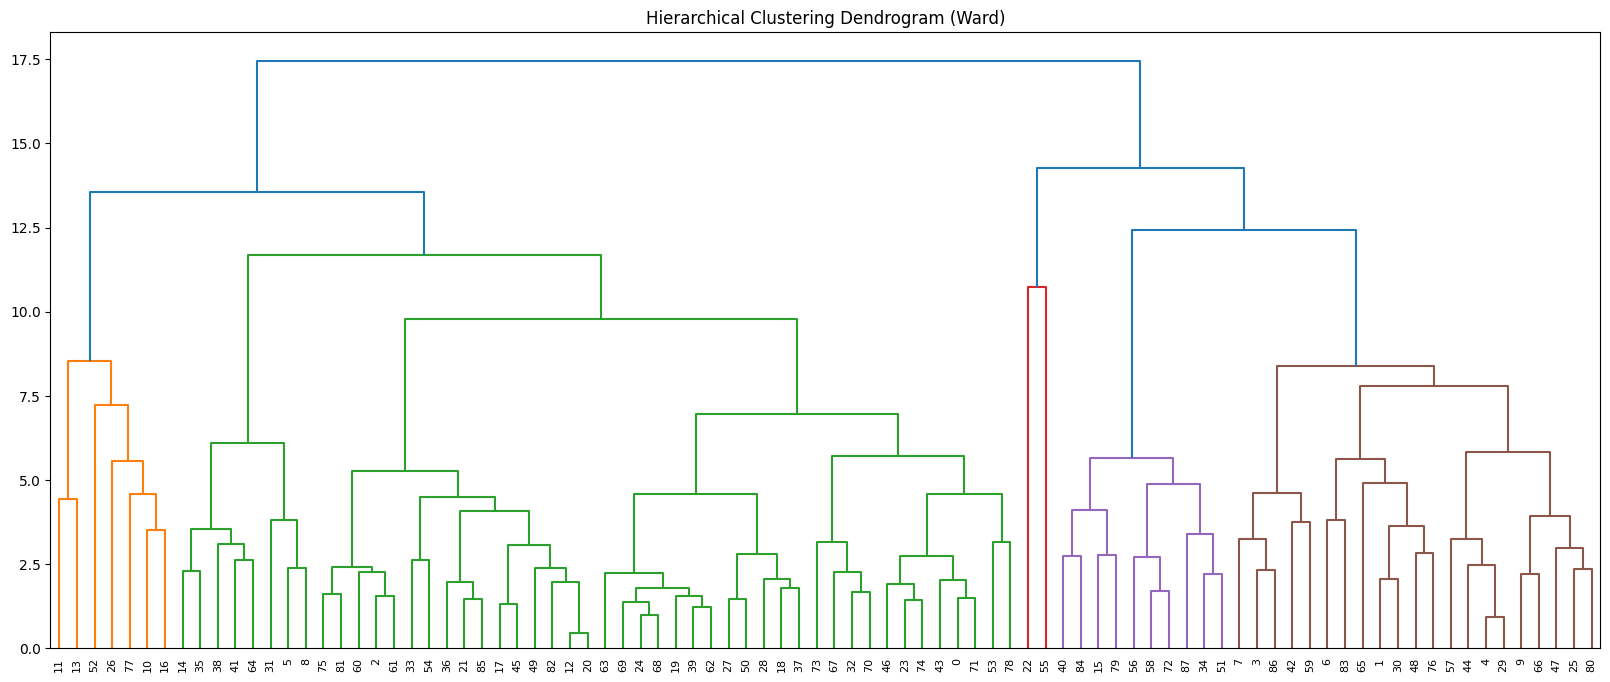

In [73]:
from scipy.cluster.hierarchy import dendrogram
from scipy.cluster.hierarchy import linkage, fcluster

plt.figure(figsize=(20, 8))

Z = linkage(X_scaled, 'ward')

_ = dendrogram(Z,leaf_rotation=90, leaf_font_size=8)

plt.title("Hierarchical Clustering Dendrogram (Ward)")
plt.show()

In [98]:
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import fcluster

k_list = [4,5,6,7,8]
rows = []

for k in k_list:
    labels = fcluster(Z, t=k, criterion='maxclust')
    sil = silhouette_score(X_scaled, labels, metric='euclidean')
    rows.append({'k': k, 'silhouette': sil})

k_eval = pd.DataFrame(rows).sort_values('silhouette', ascending=False)
k_eval


,k,silhouette
3,7,0.173622
2,6,0.170743
1,5,0.164988
0,4,0.148974
4,8,0.122774


In [78]:
best_k = int(k_eval.iloc[0]['k'])
cat_level['cluster_h'] = fcluster(Z, t=best_k, criterion='maxclust').astype(int)

cat_level['cluster_h'].value_counts().sort_index()


,count
cluster_h,
1,7
2,8
3,40
4,1
5,1
6,10
7,21


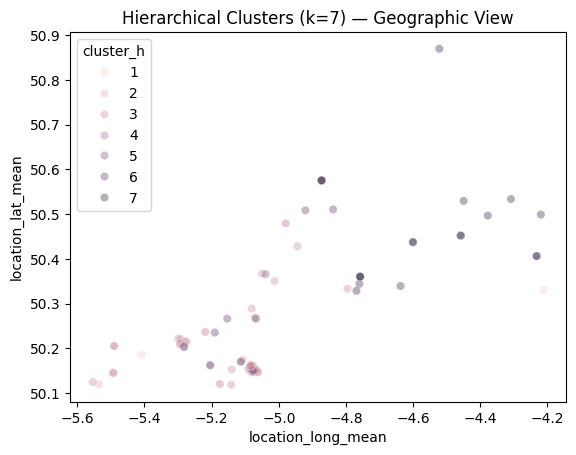

In [79]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(
    data=cat_level,
    x='location_long_mean',
    y='location_lat_mean',
    hue='cluster_h',
    alpha=0.35
)
plt.title(f"Hierarchical Clusters (k={best_k}) — Geographic View")
plt.show()



In [80]:
cluster_profile_h = cat_level.groupby('cluster_h')[feature_cols].mean()
cluster_profile_h


,location_lat_mean,location_lat_std,location_long_mean,location_long_std,ground_speed_mean,ground_speed_std,ground_speed_max,height_above_ellipsoid_mean,height_above_ellipsoid_std,hrs_indoors,hunt,prey_p_month,n_cats
cluster_h,,,,,,,,,,,,,
1,50.241037,0.000495,-5.072982,0.000834,2947.353648,4434.845005,31001.142857,98.809444,93.508887,14.642857,0.714286,1.071429,3.142857
2,50.151457,0.000320,-5.189426,0.000468,1937.235084,2508.619709,16443.000000,55.336346,52.072759,15.000000,0.0,0.000000,2.250000
3,50.194604,0.000351,-5.157771,0.000451,1876.930879,2407.212340,16976.700000,79.930582,53.602594,12.375000,1.0,2.525000,1.825000
4,50.479436,0.001692,-4.979453,0.003178,2348.270270,2864.985927,17136.000000,202.222703,482.156134,2.500000,0.0,0.000000,1.000000
5,50.365857,0.002685,-5.039284,0.008109,1865.647059,2342.272223,20844.000000,73.901471,24.066018,12.500000,1.0,3.000000,3.000000
6,50.247886,0.000494,-5.075719,0.000615,1718.699192,2287.756760,19702.800000,97.373814,47.971346,6.500000,1.0,15.500000,2.300000
7,50.458912,0.000628,-4.607453,0.001029,1658.236955,2039.832201,14526.857143,106.154453,66.145339,11.071429,1.0,4.071429,2.095238


In [81]:
# Distribution by gender across the SAME underlying clusters
ct = pd.crosstab(cat_level['animal_sex'], cat_level['cluster_h'], normalize='index')
ct


cluster_h,1,2,3,4,5,6,7
animal_sex,,,,,,,
f,0.105263,0.052632,0.50,0.00,0.00,0.105263,0.236842
m,0.060000,0.120000,0.42,0.02,0.02,0.120000,0.240000


In [82]:
from scipy.stats import chi2_contingency

ct_count = pd.crosstab(cat_level['animal_sex'], cat_level['cluster_h'])
chi2, p, dof, expected = chi2_contingency(ct_count)

chi2, p


(np.float64(3.5001503759398487), np.float64(0.7439496884212926))

In [83]:
if p < 0.05:
    conclusion = (
        "Gender is associated with different distributions across the SAME spatial–lifestyle clusters "
        "(i.e., shared underlying structure with different allocations)."
    )
else:
    conclusion = (
        "We do not find strong evidence that gender shifts the distribution across the underlying spatial–lifestyle clusters."
    )

conclusion


'We do not find strong evidence that gender shifts the distribution across the underlying spatial–lifestyle clusters.'

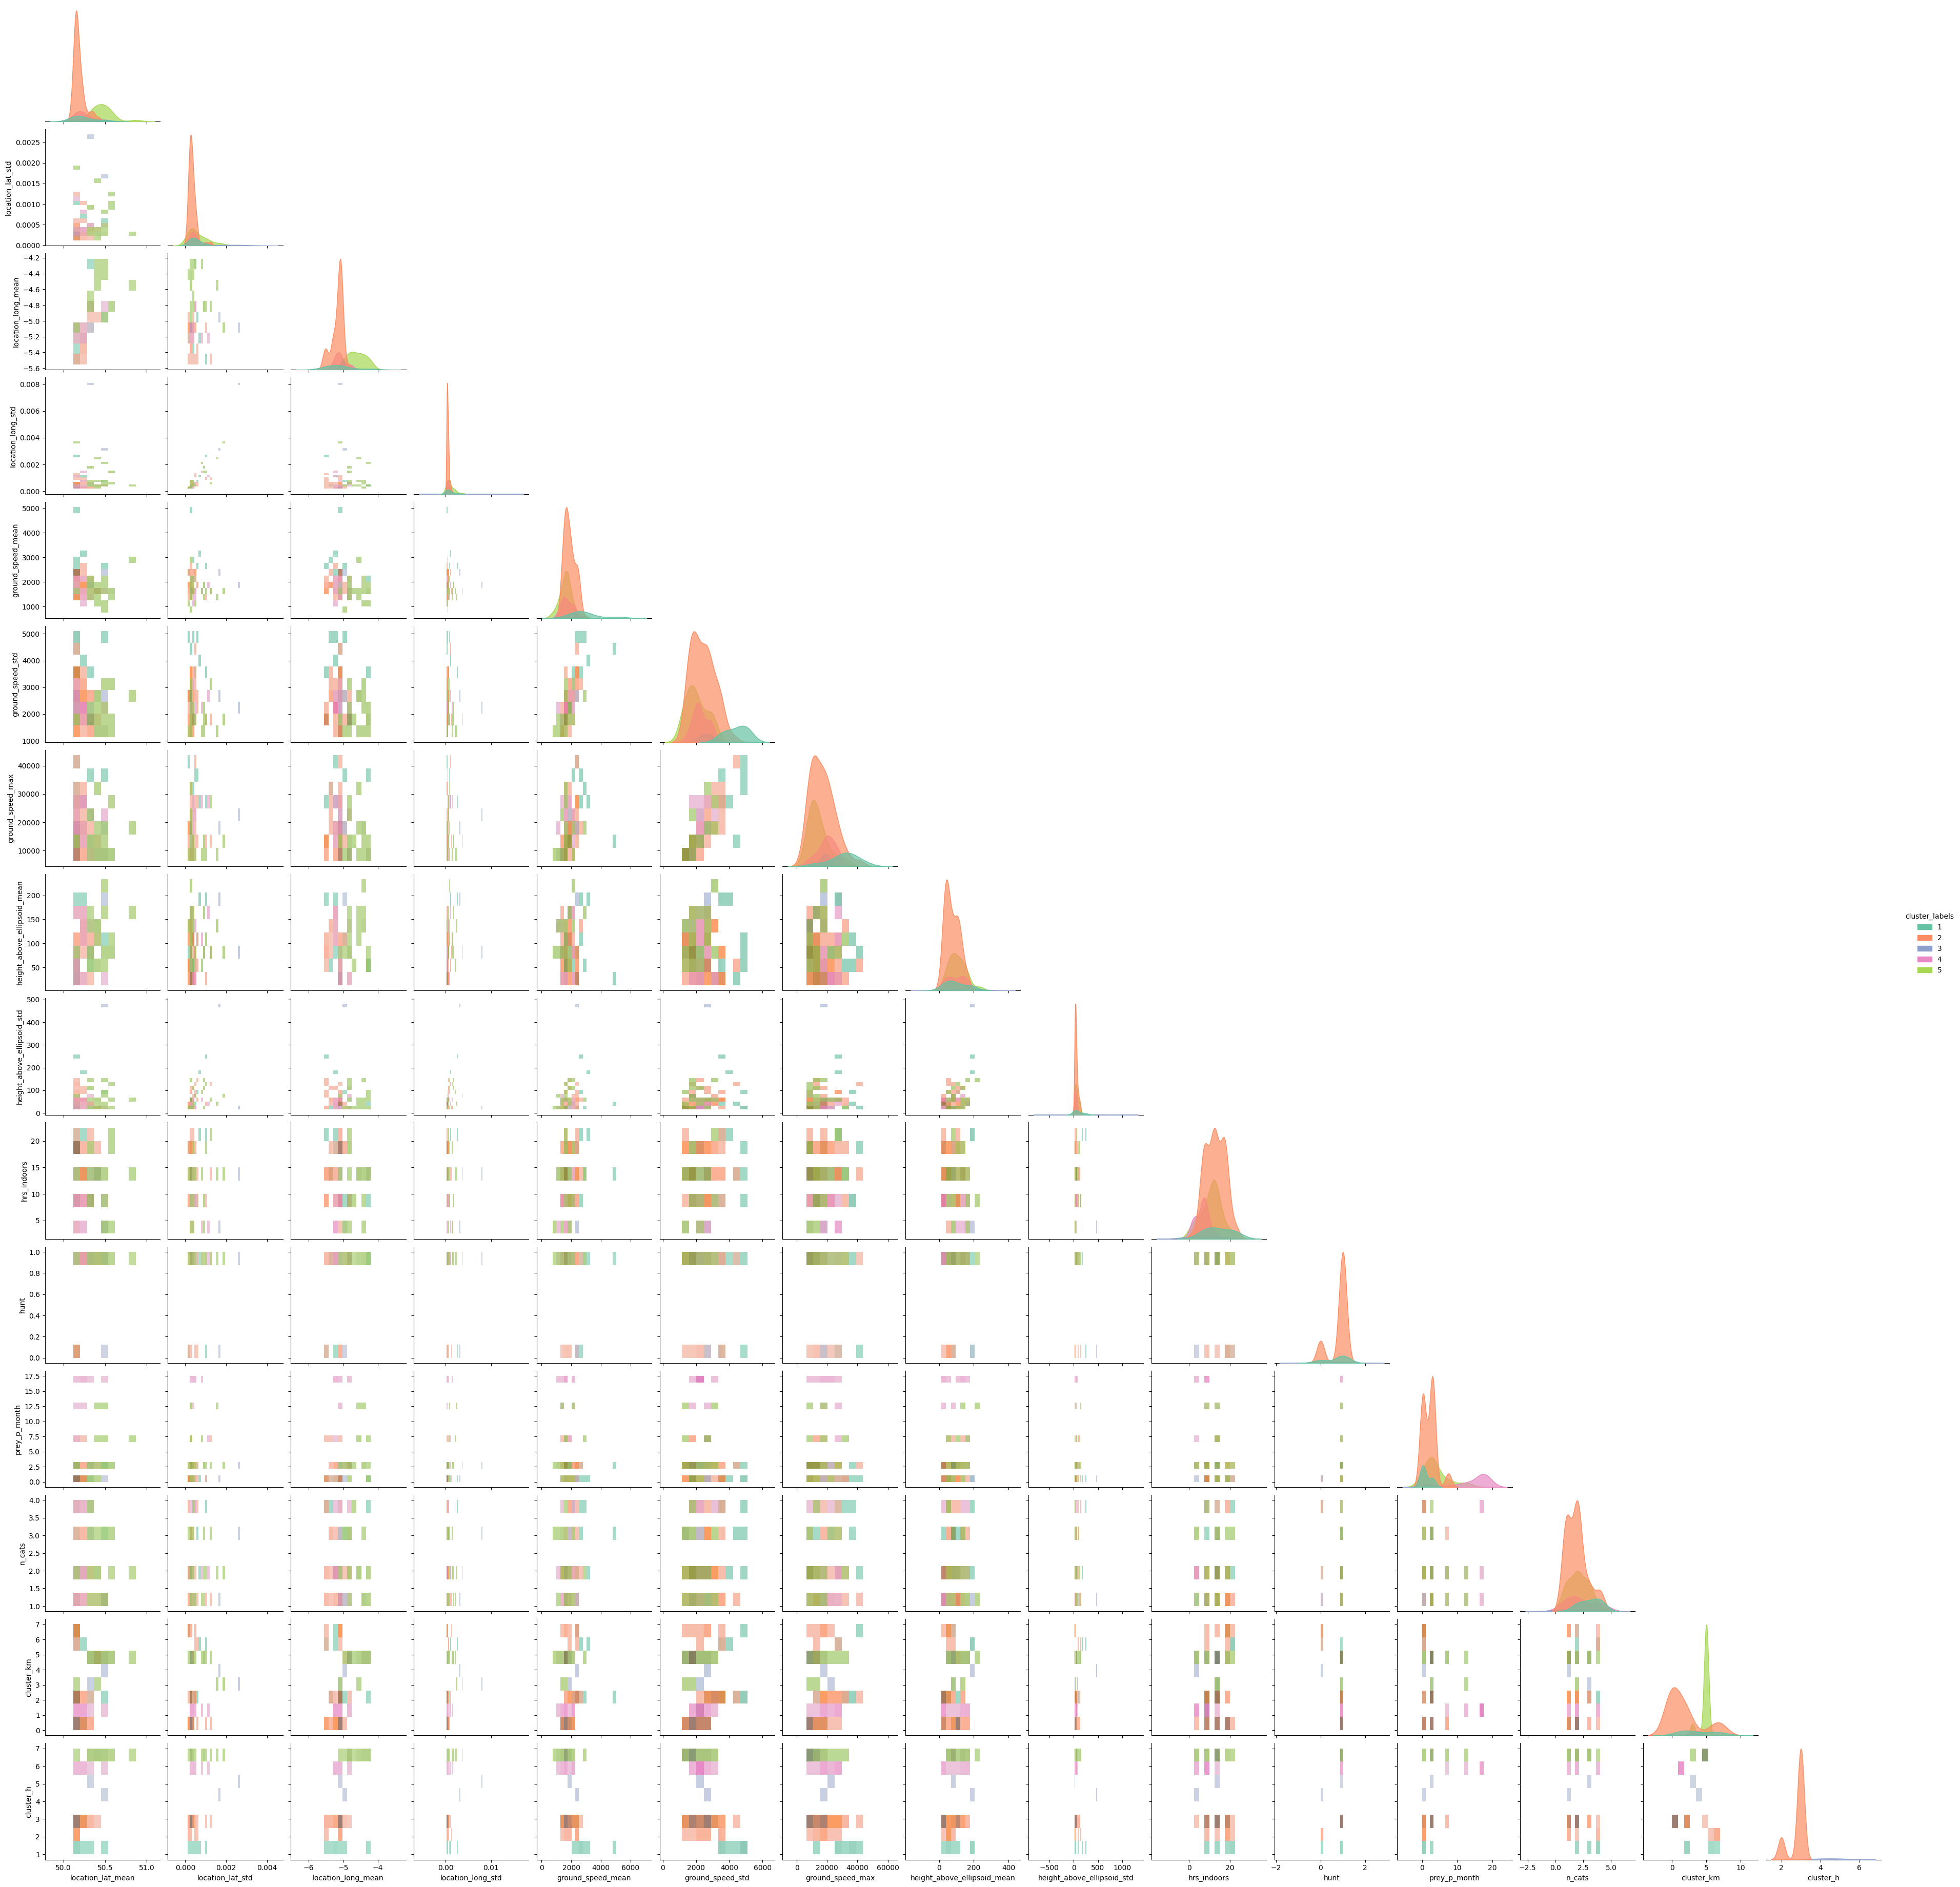

In [85]:
sns.pairplot(cat_level, kind="hist", diag_kind="kde", corner=True, hue="cluster_labels", palette="Set2",
    plot_kws={'alpha': 0.7}, # Adjusts transparency of the scatter points (0.0 to 1.0)
    diag_kws={'alpha': 0.7}  # Adjusts transparency of the diagonal plots (histograms/KDEs)
    )

In [70]:
profile = cat_level.groupby("cluster_h")[feature_cols].mean()
profile


,location_lat_mean,location_lat_std,location_long_mean,location_long_std,ground_speed_mean,ground_speed_std,ground_speed_max,height_above_ellipsoid_mean,height_above_ellipsoid_std,hrs_indoors,hunt,prey_p_month,n_cats
cluster_h,,,,,,,,,,,,,
1,50.241037,0.000495,-5.072982,0.000834,2947.353648,4434.845005,31001.142857,98.809444,93.508887,14.642857,0.714286,1.071429,3.142857
2,50.151457,0.000320,-5.189426,0.000468,1937.235084,2508.619709,16443.000000,55.336346,52.072759,15.000000,0.0,0.000000,2.250000
3,50.194604,0.000351,-5.157771,0.000451,1876.930879,2407.212340,16976.700000,79.930582,53.602594,12.375000,1.0,2.525000,1.825000
4,50.479436,0.001692,-4.979453,0.003178,2348.270270,2864.985927,17136.000000,202.222703,482.156134,2.500000,0.0,0.000000,1.000000
5,50.365857,0.002685,-5.039284,0.008109,1865.647059,2342.272223,20844.000000,73.901471,24.066018,12.500000,1.0,3.000000,3.000000
6,50.247886,0.000494,-5.075719,0.000615,1718.699192,2287.756760,19702.800000,97.373814,47.971346,6.500000,1.0,15.500000,2.300000
7,50.458912,0.000628,-4.607453,0.001029,1658.236955,2039.832201,14526.857143,106.154453,66.145339,11.071429,1.0,4.071429,2.095238


### Method 2 — KMeans

In [105]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

rows = []
for k in [4,5,6,7,8]:
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X_scaled)
    rows.append({'k': k, 'inertia': km.inertia_, 'silhouette': silhouette_score(X_scaled, labels)})

kmeans_eval = pd.DataFrame(rows)
kmeans_eval


,k,inertia,silhouette
0,4,825.951766,0.103414
1,5,737.152689,0.112725
2,6,718.711845,0.120059
3,7,640.889248,0.123269
4,8,545.648584,0.150959


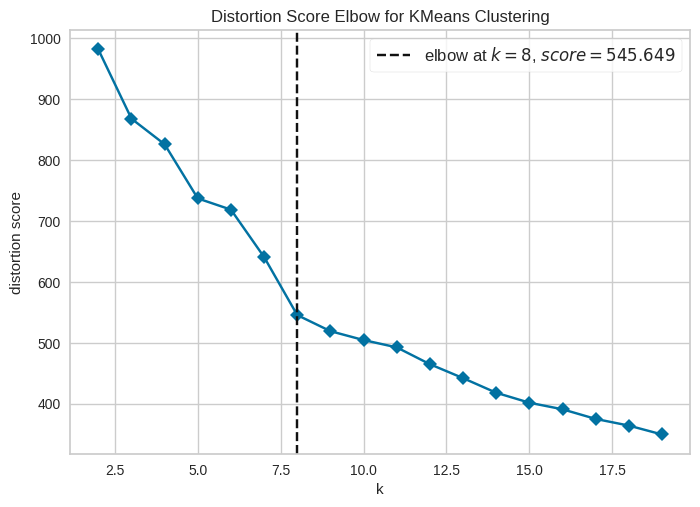

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [108]:
from yellowbrick.cluster import KElbowVisualizer
visualizer = KElbowVisualizer(
    km, k=(2, 20), metric='distortion', timings=False, random_state=42  #metric='silhouette' metric='distortion'
)
visualizer.fit(X_scaled)        # Fit the data to the visualizer
visualizer.show()        # Finalize and render the figure

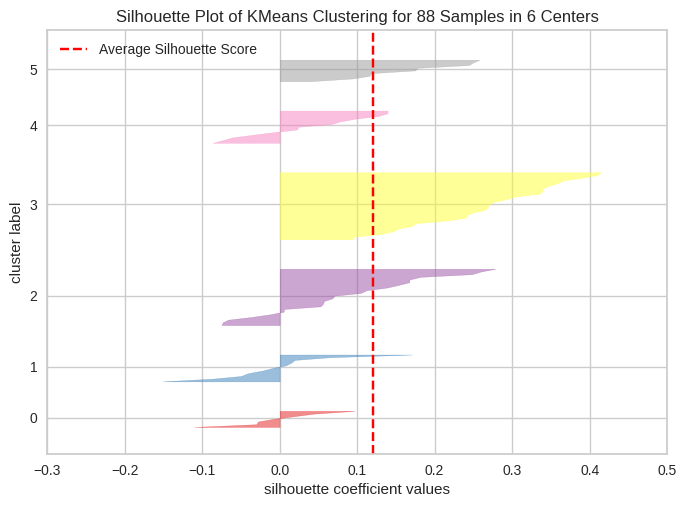

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 88 Samples in 6 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [110]:
n_clusters_kmeans = 6
from yellowbrick.cluster import SilhouetteVisualizer

kmeans_model = KMeans(n_clusters_kmeans, random_state=42)
visualizer = SilhouetteVisualizer(kmeans_model, timings=False)

visualizer.fit(X_scaled)        # Fit the data to the visualizer
visualizer.show()        # Finalize and render the figure

In [102]:
from sklearn.metrics import adjusted_rand_score

km = KMeans(n_clusters=best_k, random_state=42, n_init="auto")
cat_level['cluster_km'] = km.fit_predict(X_scaled) + 1

ari = adjusted_rand_score(cat_level['cluster_h'], cat_level['cluster_km'])
ari


0.41823183620593135

In [22]:
ct_counts = pd.crosstab(cat_level['cluster_km'], cat_level['animal_sex'])
ct_share = pd.crosstab(cat_level['cluster_km'], cat_level['animal_sex'], normalize='index')

ct_counts, ct_share


(animal_sex   f   m
 cluster_km        
 0           11  14
 1            4   6
 2           11   7
 3            1   2
 4            0   1
 5            8  12
 6            1   3
 7            2   5,
 animal_sex         f         m
 cluster_km                    
 0           0.440000  0.560000
 1           0.400000  0.600000
 2           0.611111  0.388889
 3           0.333333  0.666667
 4           0.000000  1.000000
 5           0.400000  0.600000
 6           0.250000  0.750000
 7           0.285714  0.714286)

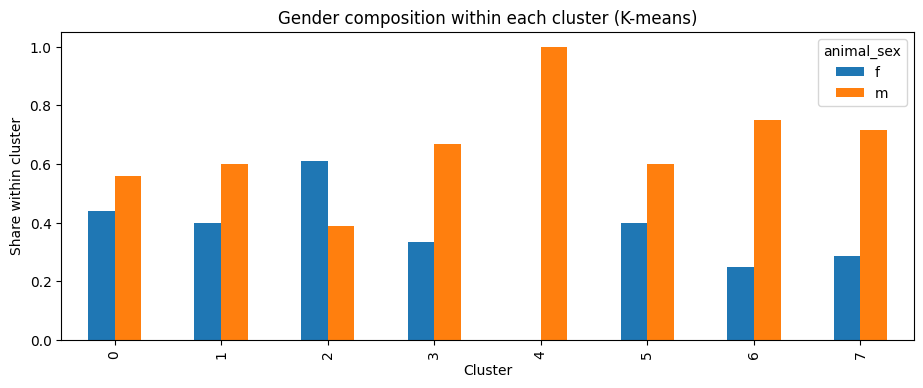

In [23]:
ct_share.plot(kind='bar', figsize=(11,4))
plt.xlabel("Cluster"); plt.ylabel("Share within cluster")
plt.title("Gender composition within each cluster (K-means)")
plt.legend(title="animal_sex")
plt.show()

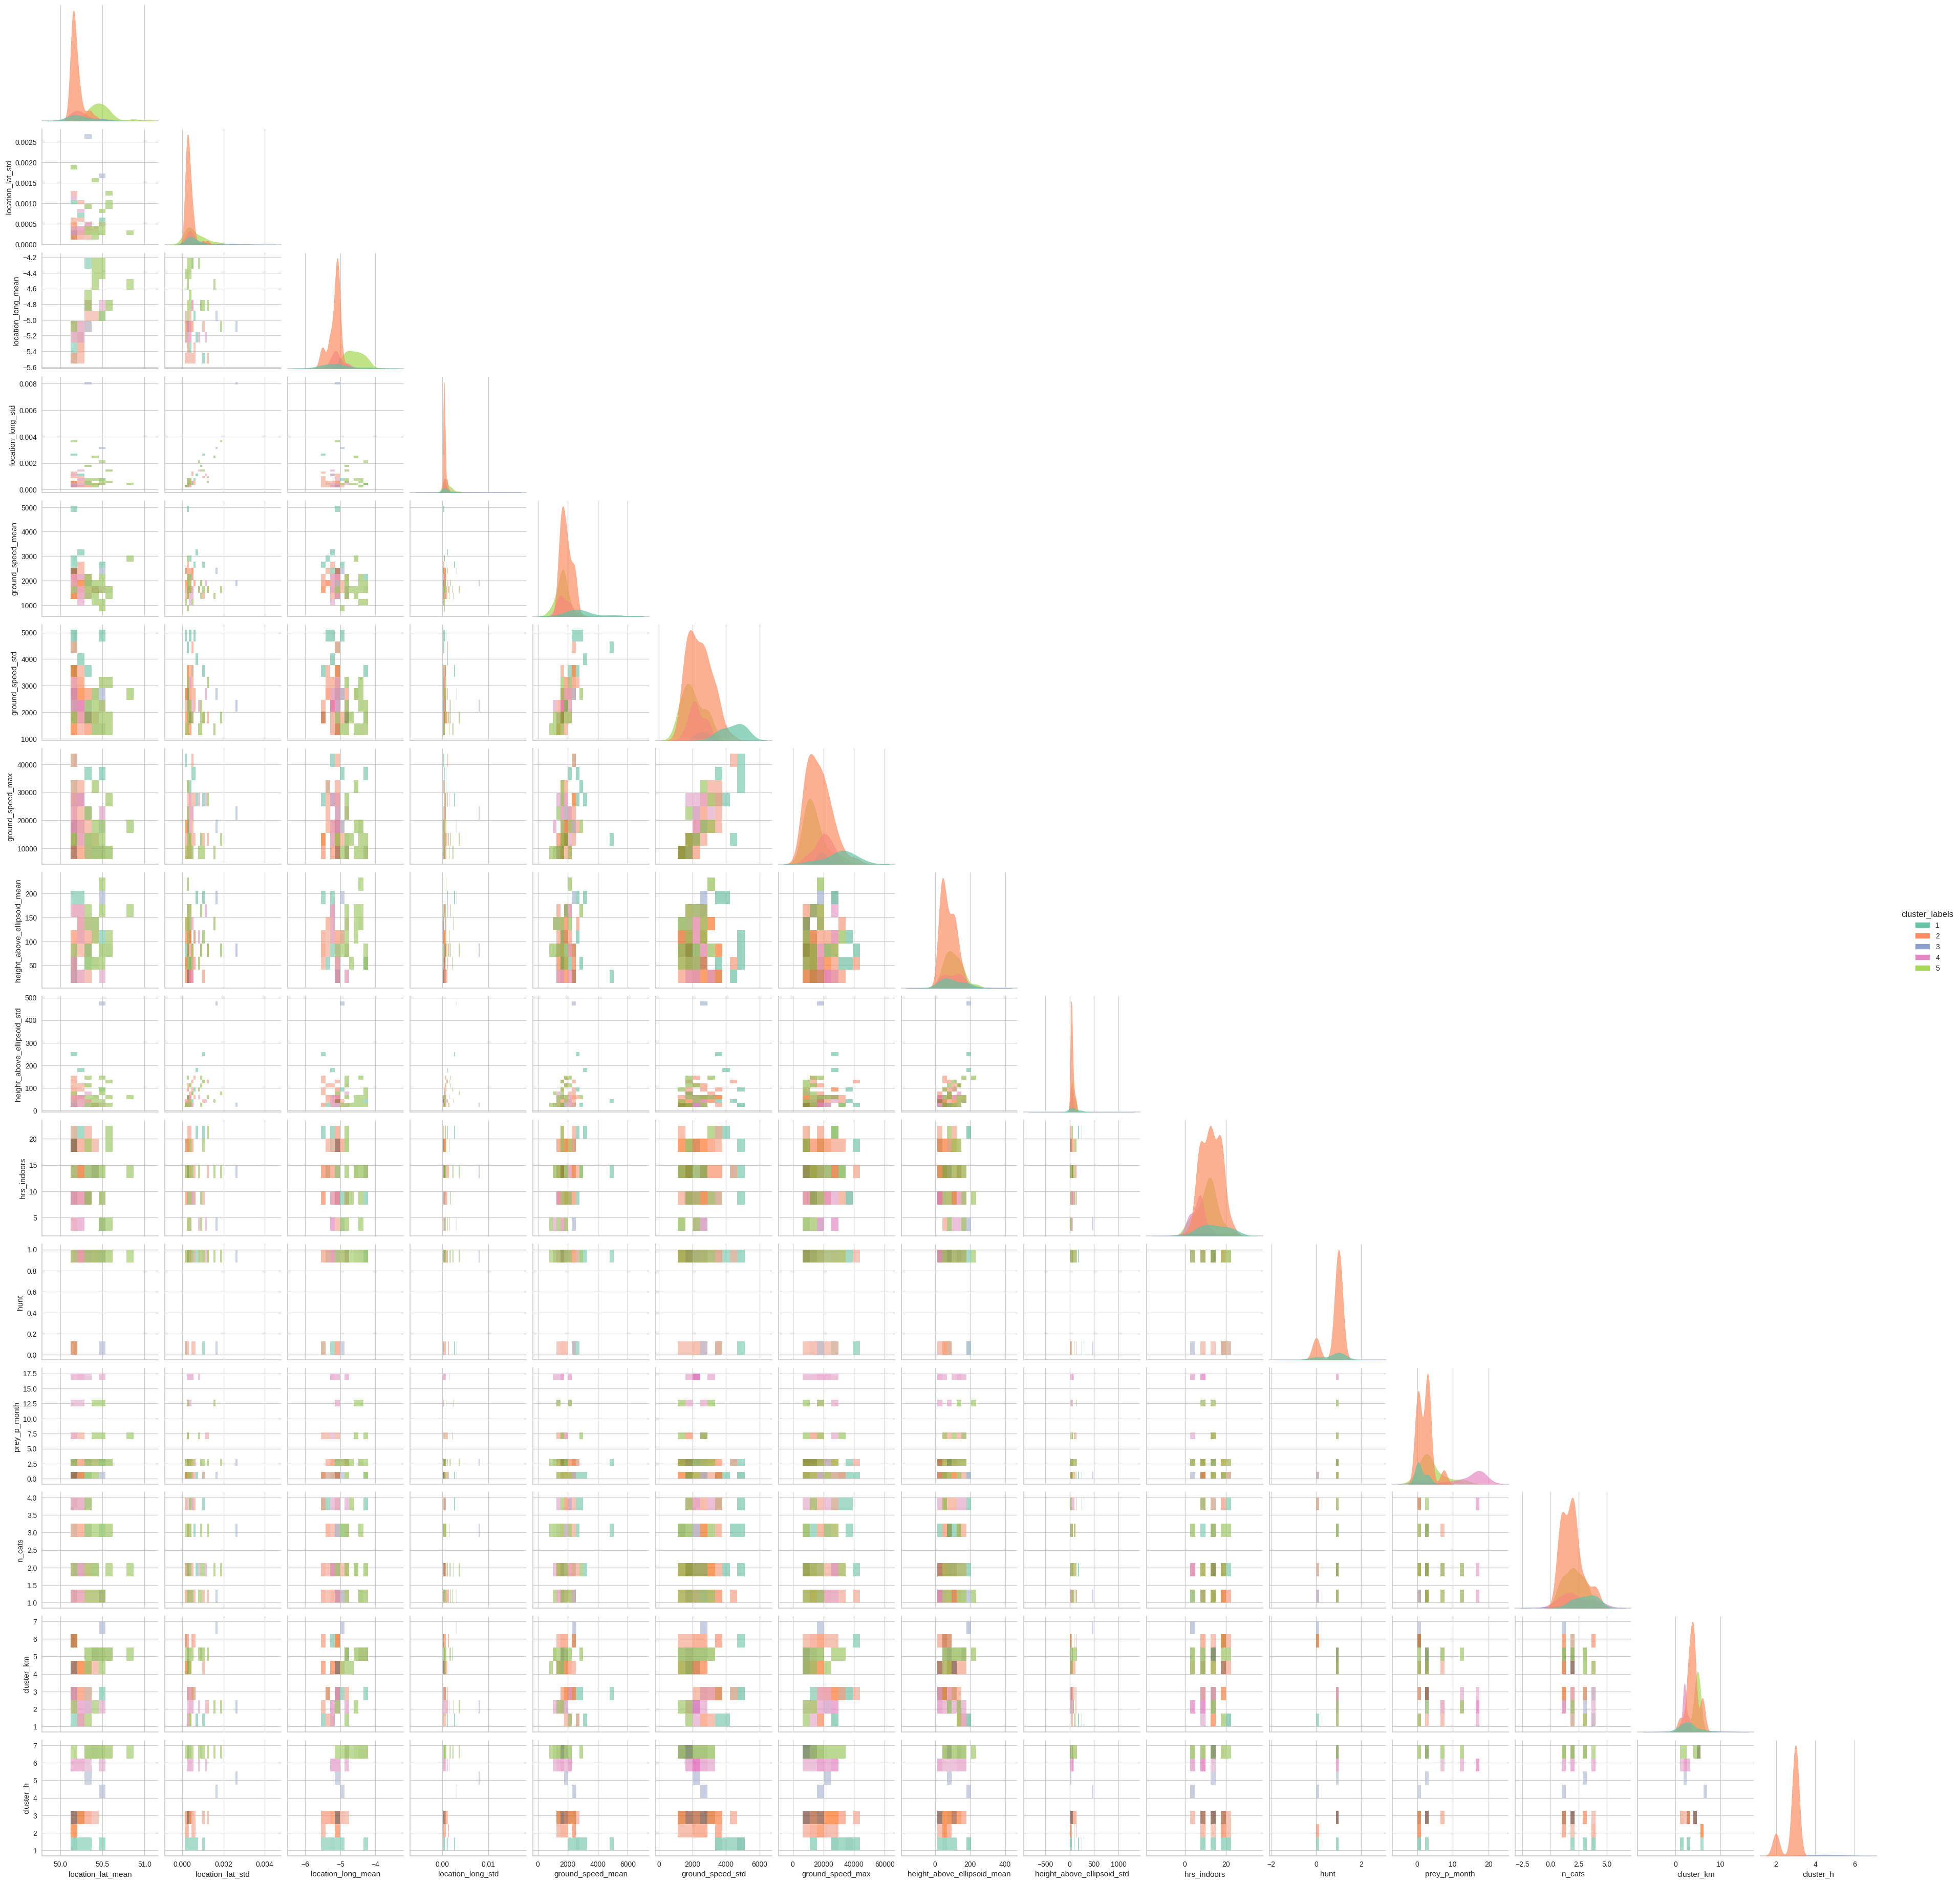

In [112]:
sns.pairplot(cat_level, hue="cluster_labels", kind="hist", diag_kind="kde", corner=True, palette="Set2",
    plot_kws={'alpha': 0.7}, # Adjusts transparency of the scatter points (0.0 to 1.0)
    diag_kws={'alpha': 0.7}  # Adjusts transparency of the diagonal plots (histograms/KDEs)
    )

/tmp/ipython-input-4130061242.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=cat_level, x='cluster_labels', y="n_cats", palette="Set2")


<Axes: xlabel='cluster_labels', ylabel='n_cats'>

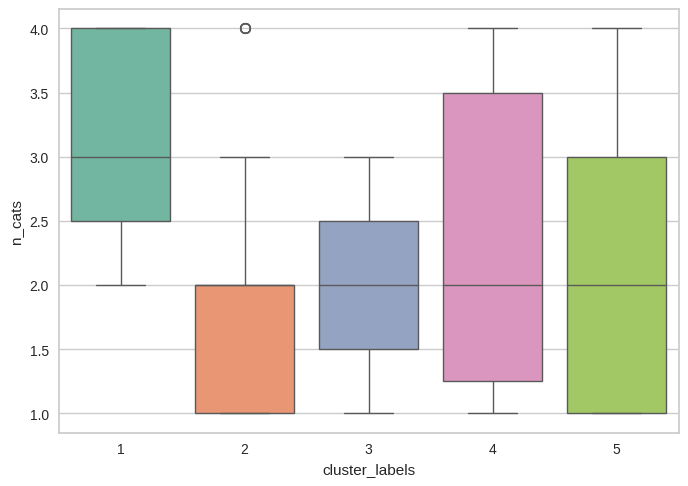

In [113]:
sns.boxplot(data=cat_level, x='cluster_labels', y="n_cats", palette="Set2")

In [24]:
from scipy.stats import chi2_contingency
import numpy as np

ct_counts = pd.crosstab(cat_level['cluster_km'], cat_level['animal_sex'])
chi2, p, dof, exp = chi2_contingency(ct_counts)

n = ct_counts.to_numpy().sum()
r, c = ct_counts.shape
cramers_v = np.sqrt((chi2 / n) / (min(r-1, c-1)))

chi2, p, cramers_v


(np.float64(4.5155395154553055),
 np.float64(0.7188452545718655),
 np.float64(0.22652361695696288))

In [25]:
profile_cols = [
    'hrs_indoors',
    'ground_speed_mean','ground_speed_max',
    'location_lat_std','location_long_std',
    'hunt','prey_p_month','n_cats'
]

cluster_profile = cat_level.groupby('cluster_km')[profile_cols].median().round(2)
cluster_profile


,hrs_indoors,ground_speed_mean,ground_speed_max,location_lat_std,location_long_std,hunt,prey_p_month,n_cats
cluster_km,,,,,,,,
0,12.5,1662.97,11844.0,0.0,0.0,1.0,3.0,2.0
1,7.5,1628.09,20214.0,0.0,0.0,1.0,17.5,2.0
2,12.5,2410.92,24894.0,0.0,0.0,1.0,3.0,2.0
3,12.5,1607.26,13284.0,0.0,0.0,1.0,3.0,2.0
4,2.5,2348.27,17136.0,0.0,0.0,0.0,0.0,1.0
5,12.5,1687.44,12204.0,0.0,0.0,1.0,3.0,2.0
6,20.0,2527.95,26586.0,0.0,0.0,0.0,0.0,4.0
7,17.5,1888.41,16200.0,0.0,0.0,0.0,0.0,1.0


## Findings & Interpretation

Our analysis reveals that UK pet cats naturally fall into a small number of distinct spatial–lifestyle patterns, rather than varying smoothly along a single spectrum of behavior. Some cats consistently remain close to home and spend more time indoors, while others exhibit broader roaming ranges and more outdoor-oriented lifestyles. These patterns reflect meaningful differences in how cats interact with their physical environment and daily routines.

When gender is considered, we find that male and female cats do not form fundamentally different types of spatial–lifestyle patterns. Instead, both genders share the same underlying set of behavioral structures, but they are distributed differently across them. In practical terms, this means gender influences how likely a cat is to fall into a particular lifestyle pattern, rather than redefining what those patterns are.

This distinction matters in real-world settings. For example, animal welfare organizations, or urban planners should not assume that male and female cats require entirely different categories of management or environmental design. Rather, interventions and policies can be structured around a common set of behavioral segments, with gender informing prioritization and risk assessment within those segments.

Overall, the findings suggest that spatial behavior among pet cats is shaped by shared lifestyle structures. While demographic factors such as gender affect how cats allocate into these structures. This supports the use of behavior-based segmentation, not only rather than gender alone, when making decisions related to pet management, urban wildlife interaction.

## Next Steps (M2)

While this analysis suggests that spatial–lifestyle patterns are largely shared across genders—and that gender primarily affects distribution rather than underlying structure—several aspects warrant further investigation.

First, the stability of these behavioral clusters has not yet been formally tested. Future research should assess whether the identified patterns persist under resampling or subsampling procedures. Given the apparent consistency of the observed structures, such robustness checks would help validate the reliability of the clustering results.

Second, it remains unclear whether spatial behavior or lifestyle-related features play the dominant role in determining cluster membership. Disentangling these feature groups and reanalyzing them separately would help clarify the primary drivers of behavioral differentiation and provide deeper insight into the mechanisms underlying the observed clustering.

Finally, this analysis does not incorporate environmental or family background factors. Because the identified clusters reflect differences in cats’ spatial interactions, integrating environmental indicators or additional demographic variables may help explain why cats exhibit these clustering patterns and whether factors beyond gender more effectively account for the observed differences.

GitHub Link: https://github.com/Nanase1994/BA820-Unsupervised-and-Unstructured-Machine-Learning-Project-